# Clustering and association rule mining Assignment

## Business Understanding

The objective of this assignment is to perform clustering on a dataset of customer locations and also to perform association rule mining on a dataset of product groups.

The purpose of the clustering is to identify optimal locations for drone delivery hubs. The goal is to minimize the distance the drones need to travel to deliver their packages. This is important for improving the efficiency of the delivery process and reducing costs. Environmental benefits can also be achieved as shorter delivery routes can lead to reduced energy consumption and lower emissions.

The association rule mining is performed to identify which product groups are often purchased together. With this information, the company can optimize their marketing to target customers with relevant products they are likely to be interested in. This can lead to increased sales and customer satisfaction.

## Data Understanding

Two datasets are used in this assignment: a dataset of customer locations and a dataset of product groups.

The customer location dataset contains the x and y coordinates of customers, while the product group dataset contains binary values (represented as 0 and 1) indicating whether a customer has purchased a product from a specific product group.

The code snippets below load the datasets and displays the first few rows of each dataset to give an overview of the data.

### Drone delivery hub locations

In [175]:
import pandas as pd

df_cust_loc = pd.read_csv('drone_cust_locations.csv', sep=';')

df_cust_loc.head()

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


 The customer location dataset is also visualized using a scatter plot to show the distribution of customer locations.

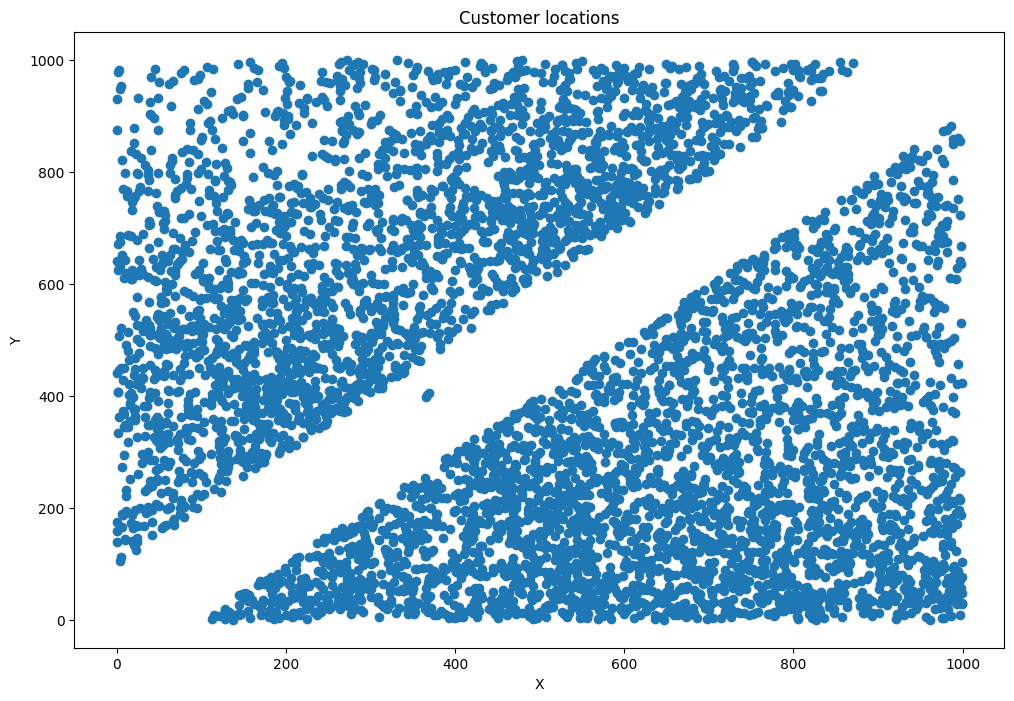

In [176]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 8))

plt.scatter(df_cust_loc["x"], df_cust_loc["y"])
plt.xlabel("X")
plt.ylabel('Y')
plt.title(f'Customer locations')

plt.show()

As can be seen from the scatter plot above, the customers are distributed fairly evenly across two regions. Between the two regions there is a gap where there are no customers. This suggests that there may be an environmental feature such as a river or a highway that separates the two regions.

### Product groups

In [177]:
df_prod_groups = pd.read_csv('drone_prod_groups.csv', sep=',')

df_prod_groups.head()

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1


## Data Preparation

Before performing any modeling, the datasets need to be prepared. In this case, the preparation involves dropping unnecessary id columns from both datasets.

Additionally, the product group dataset is converted from integer values to boolean ones, as the apriori algorithm used for association rule mining expects boolean values.

In [178]:
df_cust_loc = df_cust_loc.drop(columns=['clientid'])

df_prod_groups = df_prod_groups.drop(columns=['ID'])
df_prod_groups = df_prod_groups.astype(bool)


## Modeling

In this section, we will perform clustering on the customer location dataset and association rule mining on the product group dataset. The clustering will be done using the KMeans algorithm, while the association rule mining will be done using the apriori algorithm.

### Clustering

#### KMeans clustering

With the dataset prepared, the next step is to perform clustering on the customer locations. This is accomplished using the KMeans algorithm. The number of clusters is initially set to 3, and the calculated cluster centers are printed.

In [179]:
from sklearn.cluster import KMeans

df_cust_loc_copy = df_cust_loc.copy()

model = KMeans(n_clusters=3, random_state=42)
model.fit(df_cust_loc_copy)
print(model.cluster_centers_)

[[180.89854774 546.02319994]
 [626.30514798 179.0966322 ]
 [641.78201689 758.34167274]]


The model is the used to assign cluster labels to each customer location, and the first few rows of the dataset with the assigned cluster labels are displayed.

In [180]:
df_cust_loc_copy['cluster'] = model.labels_
df_cust_loc_copy.head(10)

,x,y,cluster
0,622.771572,164.857623,1
1,416.357298,630.193634,0
2,292.735020,567.333231,0
3,737.211288,166.225676,1
4,540.475375,682.912298,2
5,535.469492,318.439661,1
6,640.380050,870.833221,2
7,235.772075,359.048203,0
8,481.896884,661.491838,2
9,730.032789,312.177817,1


The customer locations are then visualized again using a scatter plot, this time with different colors representing different clusters. This allows us to see how the customers are grouped into clusters based on their locations. The cluster centers are also plotted as red points to show the central location of each cluster.

As can be seen from the scatter plot, the KMeans algorithm has successfully identified three clusters of customer locations. The clusters are fairly well separated.

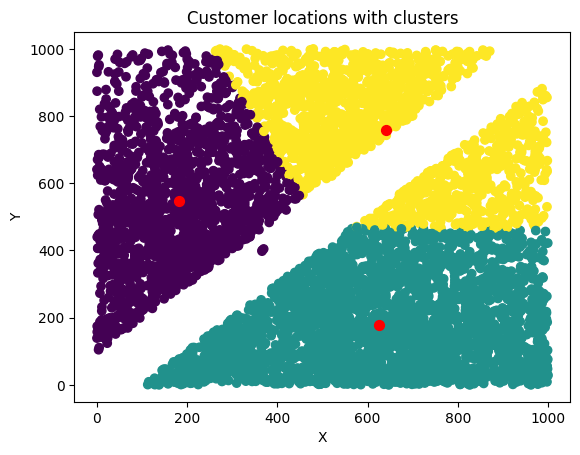

In [181]:
plt.scatter(df_cust_loc_copy["x"], df_cust_loc_copy["y"], c=df_cust_loc_copy['cluster'])
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='red', marker='o', s=50, label='Cluster Centers')
plt.xlabel("X")
plt.ylabel('Y')
plt.title(f'Customer locations with clusters')
plt.show()

To evaluate how the computation time of the KMeans algorithm changes with different numbers of clusters, a loop is used to fit the model with varying numbers of clusters (from 2 to 99) and the computation time for each fit is recorded. The results are then plotted to visualize the relationship between the number of clusters and computation time.

In [182]:
import time

computation_times = []

for n in range(2, 100):
    time_start = time.time()

    testModel = KMeans(n_clusters=n, random_state=42)
    testModel.fit(df_cust_loc)

    time_end = time.time()
    computation_times.append((n, time_end - time_start))

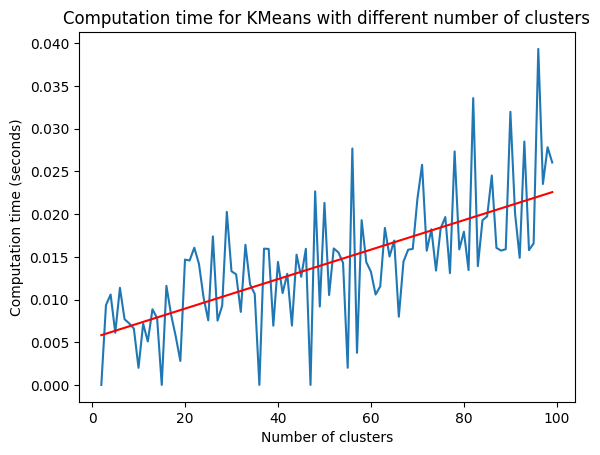

In [183]:
import numpy as np

x_plot = [n for n, t in computation_times]
y_plot = [t for n, t in computation_times]
plt.plot(x_plot, y_plot)

slope, intercept = np.polyfit(x_plot, y_plot, 1)
y_fit = [slope * n + intercept for n in x_plot]
plt.plot(x_plot, y_fit, color='red', label='Linear fit')

plt.xlabel("Number of clusters")
plt.ylabel("Computation time (seconds)")
plt.title("Computation time for KMeans with different number of clusters")

plt.show()

As can be seen from the plot, the computation time for the KMeans algorithm increases moderately as the number of clusters increases. The linear fit suggests that the relationship between the number of clusters and computation time is approximately linear.

To determine the optimal number of clusters for the KMeans algorithm, the elbow method is used. This involves calculating the within-cluster sum of squares (WCSS) for different numbers of clusters and plotting the results.

#### Elbow method for determining optimal number of clusters

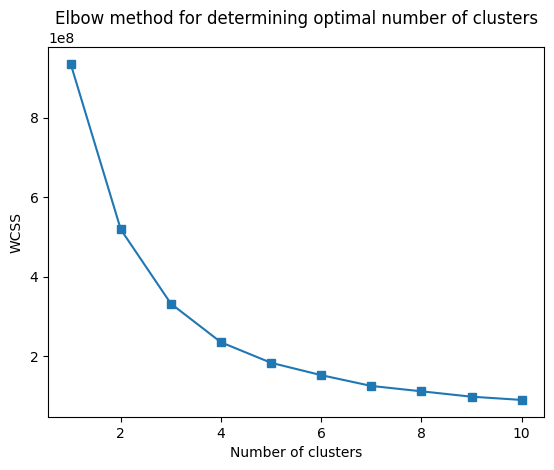

In [184]:
wcss = []

for n in range(1, 11):
    model = KMeans(n_clusters=n, random_state=42)
    model.fit(df_cust_loc)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss, marker="s")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow method for determining optimal number of clusters")
plt.show()

The point at which the WCSS starts to decrease more slowly (the "elbow") indicates the optimal number of clusters. In this case, the elbow appears to be at around 4 clusters, suggesting that using 4 clusters for the KMeans algorithm may be optimal for this dataset.

Finally, the KMeans algorithm is run again with 4 clusters, and the customer locations are visualized with the new cluster assignments. The plot shows that the customers are now grouped into 4 clusters, which may provide a better representation of the underlying structure of the data compared to using 3 clusters.

In [185]:
df_cust_loc_copy = df_cust_loc.copy()

model = KMeans(n_clusters=4, random_state=42)
model.fit(df_cust_loc)

df_cust_loc_copy ['cluster'] = model.labels_
df_cust_loc_copy.head(10)

,x,y,cluster
0,622.771572,164.857623,1
1,416.357298,630.193634,3
2,292.735020,567.333231,3
3,737.211288,166.225676,1
4,540.475375,682.912298,2
5,535.469492,318.439661,0
6,640.380050,870.833221,2
7,235.772075,359.048203,3
8,481.896884,661.491838,2
9,730.032789,312.177817,1


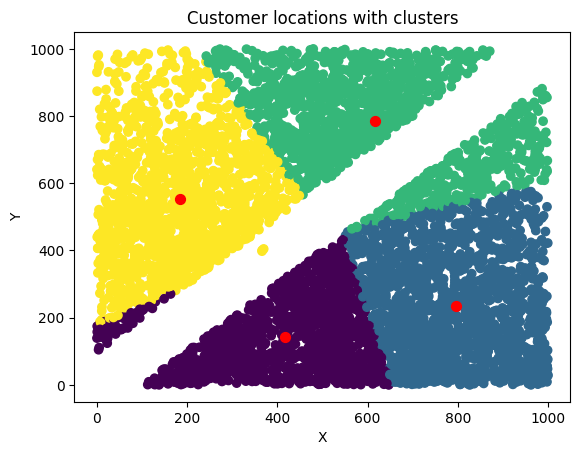

In [186]:
plt.scatter(df_cust_loc_copy["x"], df_cust_loc_copy["y"], c=df_cust_loc_copy['cluster'])
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='red', marker='o', s=50, label='Cluster Centers')
plt.xlabel("X")
plt.ylabel('Y')
plt.title(f'Customer locations with clusters')
plt.show()

The plot seems resonable, as the customers are fairly evenly distributed amongst the clusters. The KMeans algorithm was able to identify reasonable drone delivery hub locations based on the customer distribution, and using 4 clusters seems to provide a better representation of the data compared to using 3 clusters.

#### Agglomerative clustering

To see how the results of the KMeans algorithm compare to another clustering method, agglomerative clustering is also performed on the customer location dataset with varying numbers of clusters, and the computation times are recorded and plotted in the same way as for KMeans. This allows us to compare the computational efficiency of the two clustering algorithms.

Since the couple of first and last points in the plot for KMeans were outliers (even when using different values for the range of clusters), the plot for agglomerative clustering is plotted without the first two and last three points to make it more comparable to the KMeans plot.

In [187]:
from sklearn.cluster import AgglomerativeClustering

computation_times = []

for n in range(2, 100):
    time_start = time.time()

    testModel = AgglomerativeClustering(n_clusters=n)
    testModel.fit(df_cust_loc)

    time_end = time.time()
    computation_times.append((n, time_end - time_start))

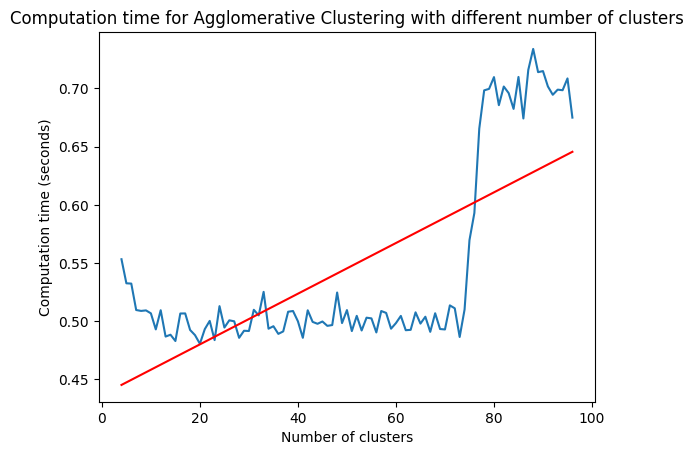

In [188]:
x_plot = [n for n, t in computation_times[2:-3]]
y_plot = [t for n, t in computation_times[2:-3]]
plt.plot(x_plot, y_plot)

slope, intercept = np.polyfit(x_plot, y_plot, 1)
y_fit = [slope * n + intercept for n in x_plot]
plt.plot(x_plot, y_fit, color='red', label='Linear fit')

plt.xlabel("Number of clusters")
plt.ylabel("Computation time (seconds)")
plt.title("Computation time for Agglomerative Clustering with different number of clusters")

plt.show()

With this plot, we can see that the computation time for agglomerative clustering does not seem to increase as the number of clusters increases, which is expected as agglomerative clustering does not require fitting a model for each number of clusters like KMeans does. Instead, it builds a hierarchy of clusters and can be more efficient for certain datasets, especially when the number of clusters is large. However, the actual computational time for this dataset is a magnitude higher than for KMeans, which suggests that KMeans may be a more efficient choice for this dataset as it is relatively small and the number of clusters is not too large.

### Association Rule Mining

The association rule mining is performed using the apriori algorithm to generate frequent itemsets and then using the association_rules function to generate rules based on confidence. The code below iterates through different values of minimum support and minimum confidence to find the number of rules generated for each combination of parameters. The results are stored in a dataframe for easy inspection.

In [189]:
from mlxtend.frequent_patterns import apriori, association_rules

supp_levels = [0.04, 0.06, 0.08, 0.10, 0.12, 0.14]
conf_levels = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

summary = []

for s in supp_levels:
    itemsets = apriori(df_prod_groups, min_support=s, use_colnames=True)

    for c in conf_levels:
        rule_set = association_rules(
            itemsets,
            metric="confidence",
            min_threshold=c
        )

        summary.append({
            "support_threshold": s,
            "confidence_threshold": c,
            "rule_count": len(rule_set)
        })

results_df = pd.DataFrame(summary)
print(results_df.sort_values("rule_count", ascending=False))


    support_threshold  confidence_threshold  rule_count
0                0.04                   0.3           6
1                0.04                   0.4           6
8                0.06                   0.4           6
7                0.06                   0.3           6
2                0.04                   0.5           5
9                0.06                   0.5           5
3                0.04                   0.6           4
15               0.08                   0.4           4
16               0.08                   0.5           4
10               0.06                   0.6           4
22               0.10                   0.4           4
23               0.10                   0.5           4
21               0.10                   0.3           4
14               0.08                   0.3           4
24               0.10                   0.6           3
17               0.08                   0.6           3
4                0.04                   0.7     

Since the number of rules generated can vary greatly based on the chosen support and confidence thresholds, it is important to select thresholds that yield a manageable and meaningful set of rules. In this case, a support threshold of 0.1 and a confidence threshold of 0.5 were selected for further analysis, as they provide a good balance between the number of rules generated and their potential usefulness.

In [190]:
frequent_items = apriori(df_prod_groups, min_support=0.04, use_colnames=True)
rules_found = association_rules(frequent_items, metric="confidence", min_threshold=0.6)
rules_found = rules.sort_values(by="confidence", ascending=False)
rules_found

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({ Prod15}),frozenset({ Prod9}),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
2,frozenset({ Prod20}),frozenset({ Prod19}),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007
3,frozenset({ Prod19}),frozenset({ Prod20}),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007
1,frozenset({ Prod9}),frozenset({ Prod15}),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754


## Evaluation

Both the clustering and association rule mining results need to be evaluated to determine their usefulness and validity. For clustering, the silhouette score was used to evaluate the quality of the clusters formed by the KMeans algorithm with 4 clusters.

For association rule mining, the support, confidence, and lift values of the generated rules were evaluated to determine which rules are most significant and useful for informing marketing strategies.

### Clustering

For evaluating the clustering results, the silhouette score is calculated for the KMeans model with 4 clusters. The silhouette score measures how similar an object is to its own cluster compared to other clusters, with a higher score indicating better-defined clusters.

In [191]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(df_cust_loc_copy, model.labels_)
print(f"Silhouette score for KMeans with 4 clusters: {silhouette}")

Silhouette score for KMeans with 4 clusters: 0.40058479721590934


Since the silhoutte score gives a value between -1 and 1, with higher values indicating better-defined clusters, the silhouette score of approximately 0.4 suggests that the clusters are moderately but not very well-defined. Looking at the original scatter plot of customer locations this makes sense, as the customers are fairly evenly distributed and there are no clear gaps between the clusters. However, the KMeans algorithm was able to identify reasonable drone delivery hub locations based on the customer distribution.

### Association Rule Mining

The most important values to evaluate the association rules are support, confidence, and lift. Support indicates how frequently the itemset appears in the dataset, confidence indicates how often the rule is true, and lift indicates how much more likely the consequent is given the antecedent compared to if they were independent.

Even though the dataset does not provide names for the product groups, we can still evaluate the rules based on these metrics.

The rules from found with a support threshold of 0.04 and a confidence threshold of 0.6 we are able to conclude the following:

- if the customers bought product from the group 15, they are likely to have also bought from group 9 (confidence of 0.93 and lift of 4.7).
- if the customers bought product from the group 20, they are likely to have also bought from group 19 (confidence of 0.91 and lift of 4.4).
- if the customers bought product from the group 19, they are likely to have also bought from group 20 (confidence of 0.65 and lift of 4.4).
- if the customers bought product from the group 9, they are likely to have also bought from group 15 (confidence of 0.56 and lift of 4.7).

The four rules above contain two sets of rules and their inverses, which suggests that these pairs of product groups are rarely bought separately.

Given this information, the company should place these products close to each other in the store and also consider marketing them together, as customers who are interested in one are very likely to be interested in the other as well.

## Deployment

If these analyses were to be deployed in a real-world scenario, the clustering could be used to optimize the locations of drone delivery hubs, while in turn could lead to more efficient delivery routes and reduced costs. The drone delivery hubs should be placed at the cluster centers found by the k-means algorithm with 4 clusters, as this was found to be the optimal number of clusters for this dataset based on the elbow method. The agglomerative clustering results could also be considered, but the k-means results seem to provide great representation of the data and are more computationally efficient for this dataset.

The association rules could be used to inform marketing strategies, allowing the company to target customers with relevant products they are likely to be interested in, which could increase sales and customer satisfaction. The rules found indicated two pairs of product groups that are often bought together, and the company should consider placing these products close to each other in the store and marketing them together to take advantage of this association.

All in all, the insights gained from these analyses could have a significant impact on the company's operations and profitability.

If these analyses were to be deployed in a real-world scenario, the clustering could be used to optimize the locations of drone delivery hubs, while in turn could lead to more efficient delivery routes and reduced costs. The association rules could be used to inform marketing strategies, allowing the company to target customers with relevant products they are likely to be interested in, which could increase sales and customer satisfaction.

All in all, the insights gained from these analyses could have a significant impact on the company's operations and profitability.